# ASCM Model Diagnostics

This notebook presents the **scm diagnostics** research workflow and key analysis steps.

## 1. Setup

First, we generate synthetic data and fit an Augmented SCM model, following the baseline example.


In [1]:
import pandas as pd
import numpy as np
from causalis.scenarios.synthetic_control.dgp import generate_scm_gamma_26
from causalis.data_contracts import PanelDataSCM
from causalis.scenarios.synthetic_control import AugmentedSyntheticControl

# 1. Generate Data
df = generate_scm_gamma_26(
    return_panel_data=False,
    include_oracles=True,
)

# 2. Create PanelDataSCM
paneldata = PanelDataSCM(
    df=df,
    y='y',
    unit_col='unit_id',
    time_col='calendar_time',
    treated_time='treated_time'
)

# 3. Fit Model
model = AugmentedSyntheticControl(lambda_aug=50).fit(paneldata)
result = model.estimate()


## 2. Mathematical Foundations: The `pre_scale` Metric

Before running specific tests, `run_scm_diagnostics` calculates a baseline variability measure called `pre_scale` for the treated unit during the pre-treatment period. 

Most diagnostic thresholds are defined as a percentage of this scale. This ensures that the "goodness of fit" is judged relative to the inherent volatility of the data.

### Robust Scale Estimators

To avoid being misled by outliers or trends, the function calculates four different scale metrics and takes the maximum:

1. **Standard Deviation**: $\sigma = \sqrt{\frac{1}{n-1} \sum_{t=1}^{n} (x_t - \bar{x})^2}$

2. **Median Absolute Deviation (MAD)**: Scaled to be consistent with $\sigma$ for a normal distribution:
   $$MAD_{\text{scaled}} = 1.4826 \cdot \text{median}(|x_t - \text{median}(x)|)$$

3. **Interquartile Range (IQR)**: Also scaled for normal consistency:
   $$IQR_{\text{scaled}} = \frac{Q_{75} - Q_{25}}{1.349}$$

4. **First-Difference Scale**: Calculated using the standard deviation of first differences, useful when there is a trend or high autocorrelation. Since $\text{Var}(X_t - X_{t-1}) = 2\sigma^2$ for i.i.d. variables, we scale by $\sqrt{2}$:
   $$\text{diff\_scale} = \frac{\text{std}(\Delta x)}{\sqrt{2}}$$

$$\text{pre\_scale} = \max(\sigma, MAD_{\text{scaled}}, IQR_{\text{scaled}}, \text{diff\_scale})$$


## 3. Diagnostic Tests

The diagnostics are divided into fit-based checks and model-based (weight) checks.


### A. Fit-Based Diagnostics

1. **Pre-treatment RMSE**: Checks if the overall fit in the pre-treatment period is tight.
   $$RMSE_{pre} = \sqrt{\frac{1}{T_{pre}} \sum_{t=1}^{T_{pre}} (y_t - \hat{y}_t)^2} \le 0.20 \cdot \text{pre\_scale}$$

2. **Max Absolute Pre-gap**: Checks for extreme outliers in the pre-treatment period.
   $$\max_{t \in \text{pre}} |y_t - \hat{y}_t| \le 0.50 \cdot \text{pre\_scale}$$

3. **Mean Gap Last K Pre-periods**: Checks for pre-trend drift right before the treatment (typically $k=3$). If the average gap is far from zero, the parallel trends assumption might be failing just as treatment begins.
   $$|\frac{1}{k} \sum_{t=T_{pre}-k+1}^{T_{pre}} (y_t - \hat{y}_t)| \le 0.25 \cdot \text{pre\_scale}$$


### B. Weight-Based Diagnostics

Augmented SCM (ASCM) allows for weights that can be negative or greater than one to achieve a better pre-treatment fit (extrapolation). However, extreme weights indicate that the counterfactual relies on unstable linear combinations of donors.

1. **Max Absolute Weight**: Detects extreme individual weights.
   $$\max |w_j| \le 2.0 \text{ (default)}$$

2. **L1 Norm of Weights**: Detects when the total sum of absolute weights is too high.
   $$\sum |w_j| \le 5.0 \text{ (default)}$$

3. **Negative Weight Share**: Measures how much the estimate relies on negative weights (pure extrapolation vs. interpolation).
   $$\frac{\sum_{w_j < 0} |w_j|}{\sum |w_j|} \le 0.30$$


## 4. Running the Diagnostics

We can now execute `run_scm_diagnostics` and inspect the results table.


In [2]:
from causalis.scenarios.synthetic_control.refutation import run_scm_diagnostics

diagnostics_df = run_scm_diagnostics(result, paneldata)
diagnostics_df


,test,flag,value,threshold,message
0,pre_rmse_augmented,GREEN,0.366248,<= 0.5254,Pre-treatment RMSE is within tolerance.
1,max_abs_pre_gap_augmented,GREEN,0.988290,<= 1.314,Largest pre-treatment gap is within tolerance.
2,mean_gap_last_k_pre_augmented,GREEN,0.207285,<= 0.6568,Average gap in the last 3 pre periods is cente...
3,max_abs_weight_augmented,GREEN,0.201943,<= 2,No extreme augmented donor weight detected (mo...
4,l1_norm_weights_augmented,GREEN,2.245170,<= 5,Total absolute augmented weight mass is contro...
5,negative_weight_share,GREEN,0.277300,<= 0.3,Negative-weight share is moderate.
6,slsqp_fallback_count,GREEN,0.000000,== 0,No optimizer fallback events recorded.
7,suppressed_fit_warning_count,GREEN,0.000000,== 0,No suppressed fit warnings were captured.


## 5. Interpreting Flags

- **GREEN**: Metric is within optimal tolerance. The estimate is likely robust.
- **YELLOW**: Metric exceeds the warning threshold. Consider investigating the pre-treatment fit or donor pool. The estimate might be sensitive to small changes.
- **RED**: Indicates a severe problem, such as optimizer failure or extreme fit issues. The estimate should be treated with high skepticism.


## 6. Placebo Tests

Robustness tests check if the treatment effect is unique to the treated unit and time.

### A. Placebo-in-Space (Permutation Test)

This test (Abadie et al. 2010) applies the SCM to every unit in the donor pool, treating each donor as the "treated" unit.

1. For each donor unit $j \in \text{Donors}$, we fit a synthetic control model using only the remaining donors.
2. We calculate the Root Mean Squared Prediction Error (RMSE) for both pre- and post-treatment periods:
   $$RMSE_{pre,j} = \sqrt{\frac{1}{T_{pre}} \sum_{t=1}^{T_{pre}} (y_{j,t} - \hat{y}_{j,t})^2}$$
   $$RMSE_{post,j} = \sqrt{\frac{1}{T_{post}} \sum_{t=T_{pre}+1}^{T} (y_{j,t} - \hat{y}_{j,t})^2}$$
3. We compute the **RMSPE Ratio**:
   $$R_j = \frac{RMSE_{post,j}}{RMSE_{pre,j}}$$
4. **Interpretation**: If the actual treated unit's ratio $R_{treated}$ is much larger than the distribution of $R_j$ for placebo units, it indicates that the effect is statistically significant. The **p-value** is effectively:
   $$p = \frac{\text{count}(R_j \ge R_{treated})}{N_{donors} + 1}$$

### B. Placebo-in-Time (Falsification Test)

This test shifts the treatment start date $T_{actual}$ to an earlier date $T_{placebo}$ within the true pre-treatment period.

1. We choose $T_{placebo} < T_{actual}$ and a pseudo-post-horizon $H$.
2. We fit the SCM on $[1, T_{placebo}]$ and measure the "effect" on $[T_{placebo}+1, T_{placebo}+H]$.
3. Since no treatment occurred during this period, the estimated Average Treatment Effect on the Treated (ATT) should be close to zero and statistically insignificant.
4. **Interpretation**: If the null hypothesis (ATT=0) is rejected for many placebo dates, it suggests that the parallel trends assumption is violated (e.g., due to pre-treatment anticipation effects or unobserved trends).


In [3]:
from causalis.scenarios.synthetic_control.refutation import placebo_in_space_table, placebo_in_time_table

# 1. Run Placebo-in-Space
space_table = placebo_in_space_table(result, paneldata)
space_table.head()

# 2. Run Placebo-in-Time
time_table = placebo_in_time_table(result, paneldata)
time_table.head()


,placebo_treatment_start,n_pre_before_placebo,n_post_after_placebo,average_att_placebo,ci_lower,ci_upper,p_value,rejects_zero,pre_fit_metric
0,2000-03,2,6,1.882234,-16.331756,20.096223,0.414358,False,3.892700e-09
1,2000-04,3,6,1.269647,-2.922810,5.462105,0.322397,False,4.675707e-08
2,2000-05,4,6,1.558211,-2.782112,5.898534,0.262430,False,7.740750e-09
3,2000-06,5,6,1.314722,-2.945265,5.574709,0.315493,False,8.664180e-09
4,2000-07,6,6,1.415188,-1.584680,4.415056,0.179511,False,8.107963e-09


## 7. Sensitivity Analysis

Sensitivity tests assess how dependent the final estimate is on specific assumptions or data subsets.

### Leave-One-Donor-Out (LODO) Sensitivity

A common concern in SCM is that the result might be driven by a single, idiosyncratic donor unit. This test (Abadie et al. 2015) re-estimates the model $N_{donors}$ times, each time removing one unit from the donor pool.

1. Let $J$ be the set of all available donor units.
2. For each unit $j \in J$, we fit a new model using $J \setminus \{j\}$.
3. We calculate the re-estimated treatment effect $ATT_j$ and the change relative to the full model:
   $$\Delta_j = ATT_j - ATT_{full}$$
4. **Interpretation**: 
   - Small $\Delta_j$ for all $j$ indicates a robust estimate.
   - A large $\Delta_j$ suggests that donor $j$ is highly influential. If that donor's pre-fit was poor or if it has unusual characteristics, the main estimate should be treated with caution.

### Effective Number of Donors

To understand how concentrated the weights are, we calculate the **Effective Number of Donors ($N_{eff}$)**, which is the inverse of the Herfindahl-Hirschman Index (HHI) of the weights:

$$N_{eff} = \frac{1}{\sum_{j \in J} w_j^2}$$

- $N_{eff} = 1$: The counterfactual is built using only one donor.
- $N_{eff} = N_{donors}$: All donors have equal weights ($1/N_{donors}$).

Lower $N_{eff}$ indicates higher reliance on a small subset of donors.

#### Interpreting the Results Table

- **dropped_donor**: Donor unit removed in that refit.
- **average_att_reestimated**: ATT calculated after removing that donor.
- **delta_vs_full_model**: $\Delta_j = ATT_j - ATT_{full\_model}$. Values near zero indicate the estimate is stable; large values suggest the donor is highly influential.
- **pre_rmse_reestimated**: Pre-treatment fit error after refit. A significant increase suggests the dropped donor was essential for maintaining fit quality.
- **max_weight_after_refit**: Largest donor weight in the refitted model.
- **effective_n_donors_after_refit**: The effective number of donors ($N_{eff}$) for the refitted model.


In [4]:
from causalis.scenarios.synthetic_control.refutation import leave_one_donor_out_sensitivity

# Run LODO Sensitivity
lodo_table = leave_one_donor_out_sensitivity(result, paneldata)
lodo_table.head()


,dropped_donor,average_att_reestimated,delta_vs_full_model,pre_rmse_reestimated,max_weight_after_refit,effective_n_donors_after_refit
0,donor_1,4.207858,0.262223,0.171405,0.303030,0.946472
1,donor_10,4.587795,0.642161,0.160802,0.349188,0.909245
2,donor_11,4.189136,0.243502,0.160120,0.353247,0.909496
3,donor_12,4.916255,0.970621,0.189167,0.336427,0.978294
4,donor_13,4.468127,0.522492,0.162525,0.341735,0.927949


## 8. Diagnostic Visualizations

Visualization is a critical step in assessing SCM results. It allows for a qualitative check of the pre-treatment fit and the post-treatment divergence.

### Observed vs. Synthetic Plot

This plot displays the time series of the actual treated unit alongside its synthetic counterfactual (both standard and augmented, if available).

- **Pre-treatment period**: The closer the observed and synthetic lines are, the better the model's fit. A poor pre-fit (large gaps) suggests that the donor pool cannot adequately represent the treated unit.
- **Post-treatment period**: Divergence between the lines indicates a treatment effect.

### Gap Over Time Plot

The gap plot shows the difference between the observed and synthetic outcomes:
$$Gap_t = y_{1,t} - \hat{y}_{1,t}$$

- In the **pre-treatment period**, the gap should ideally fluctuate closely around zero.
- In the **post-treatment period**, the gap represents the estimated treatment effect ($ATT_t$) at each point in time.

#### Interpreting the Gap:
- If the gap is systematically positive (or negative) after treatment, it suggests a persistent effect.
- If the gap fluctuates around zero even after treatment, it suggests no significant effect.


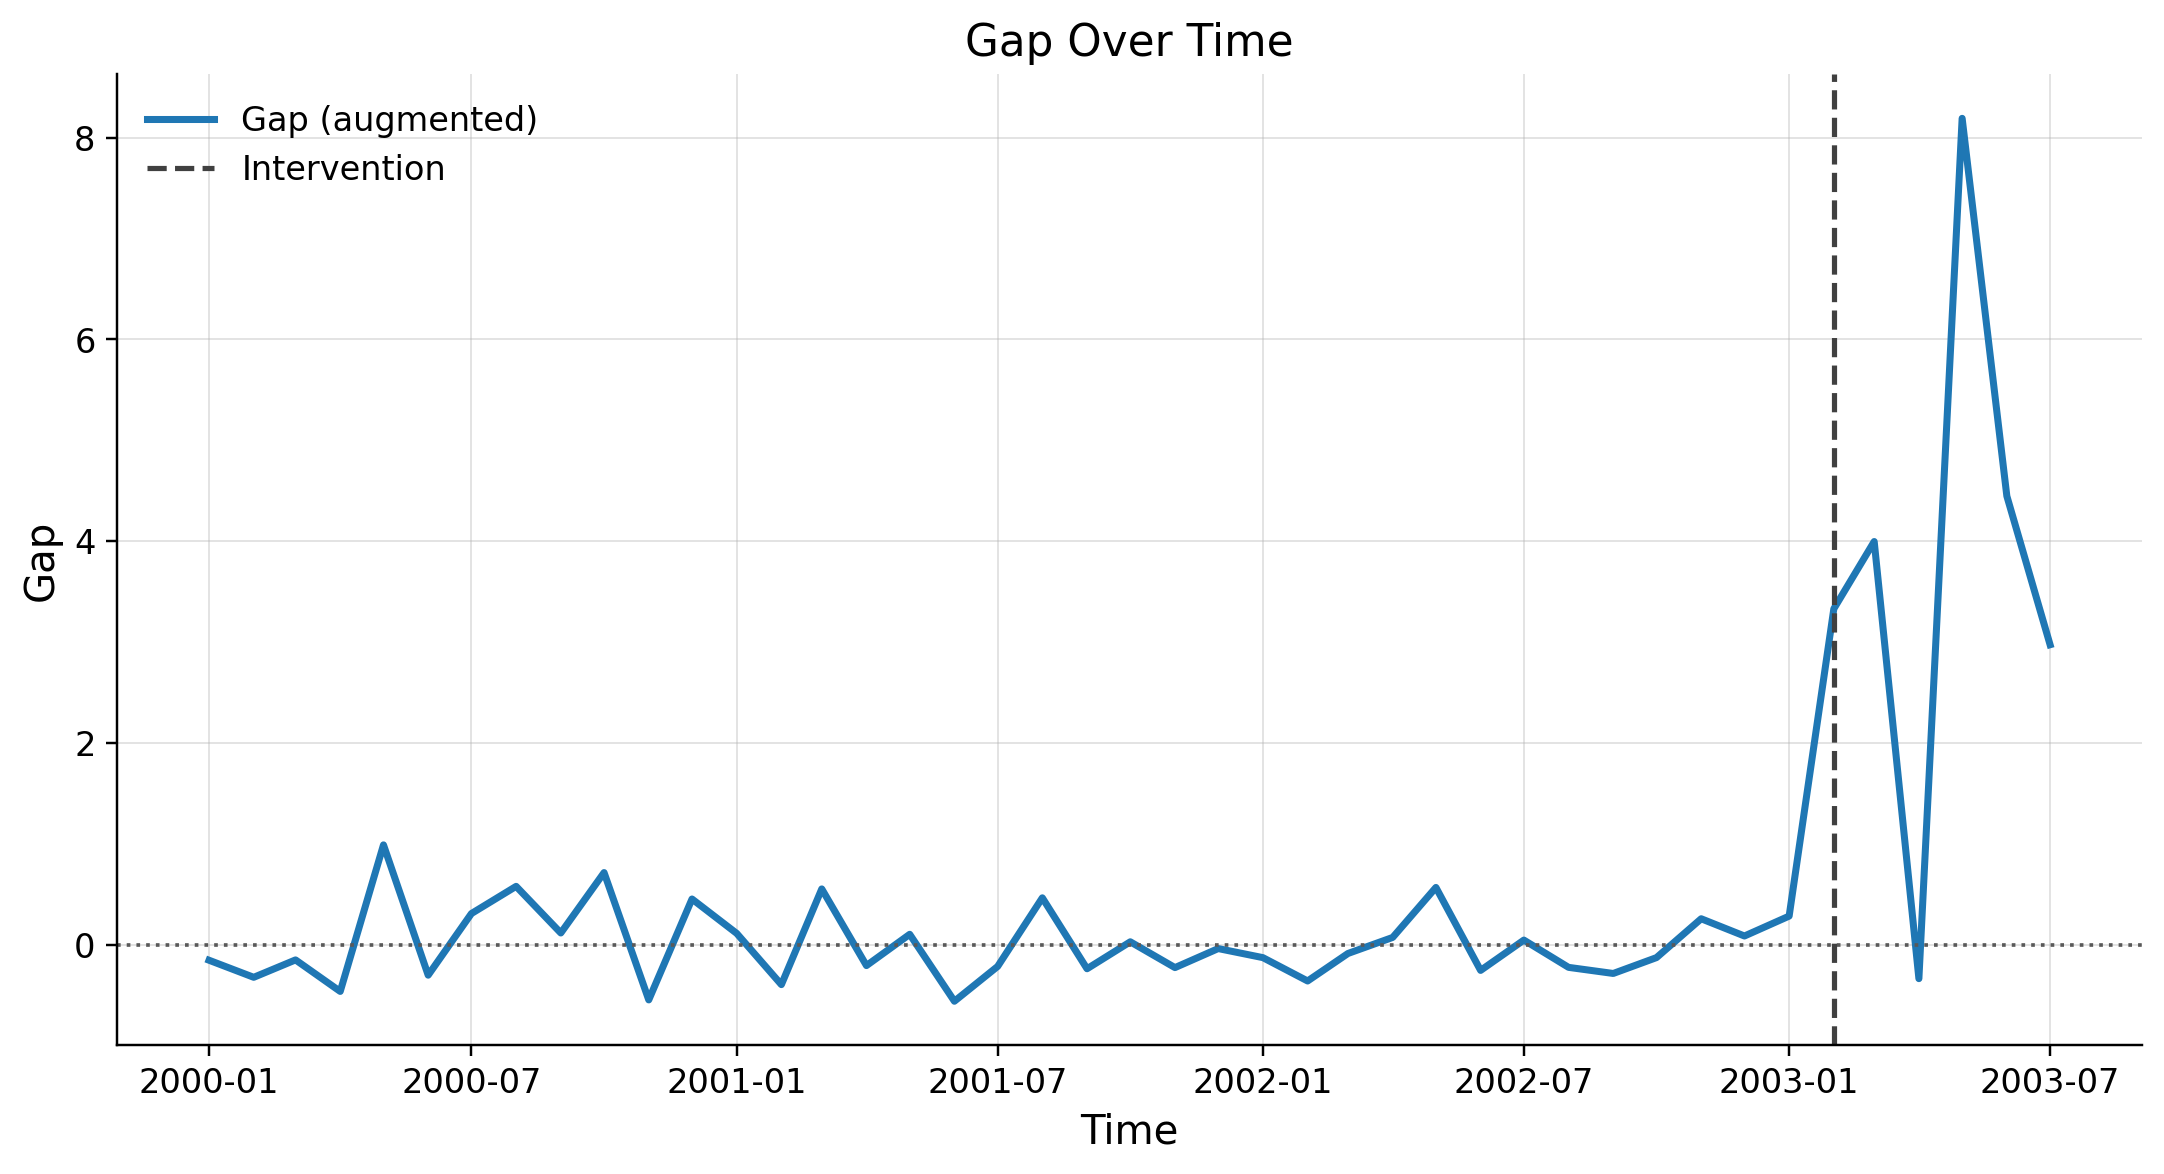

In [5]:
from causalis.scenarios.synthetic_control.refutation import (
    observed_vs_synthetic_plot, 
    gap_over_time_plot
)

# 1. Plot Observed vs. Synthetic
fig_ovs = observed_vs_synthetic_plot(result)
fig_ovs

# 2. Plot Gap Over Time
fig_gap = gap_over_time_plot(result)
fig_gap
